# Lidar autoencoder - harom architektura osszehasonlitasa

Harom modell tanul UGYANAZON az adaton. Mindharom TERBELI jellemzoterkepet
ad (nem lapitott vektort) - az RL sajat CNN feature-extractora dolgozza fel:

| modell | bemenet | mit tanul |
|---|---|---|
| `bev_ae` | nyers pontfelho | fix BEV statisztika (occupancy + z_max/z_min) -> conv AE |
| `graph_ae` | range image | dinamikus graf-konvolucio (EdgeConv) |
| `point_mae` | nyers pontfelho | maszkolt patch-rekonstrukcio (Transformer) |

## 1. Modulok, beallitasok

In [1]:
import gc
import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from lidar.point_mae import PointMAE
from lidar.bev_ae import BEVConvAE
from lidar.graph_ae import LidarAE, DDCONFIG, points_to_range_image

DATA_DIR = "dataset/lidar"
EPOCHS = 30
N_FRAMES = None           # None = minden frame

N_POINTS = 24576

# A point_mae batch-e 128-rol 64-re ment. Ok: a num_group 128 -> 256 es a
# group_size 16 -> 32 (lasd a 6. szakaszt), ami a group() cdist-jet es a
# Chamfer tavolsagmatrixat is megnoveli. MERVE, ezen a 8.3 GB-os GPU-n:
#
#     batch 32 -> 5.9 GB    batch 64 -> 6.0 GB    batch 96 -> OOM
BATCH = {"bev_ae": 768, "graph_ae": 32, "point_mae": 64}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

cuda NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.3 GB


In [2]:
def free_vram(*objects):
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def vram():
    """Aktualis GPU memoriahasznalat."""
    if not torch.cuda.is_available():
        return "n/a"
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} GB foglalt / "
            f"{torch.cuda.memory_reserved() / 1e9:.2f} GB fenntartva / "
            f"{total:.1f} GB osszes")


print("indulaskor:", vram())

indulaskor: 0.00 GB foglalt / 0.00 GB fenntartva / 8.3 GB osszes


## 2. Adatok betoltese

**Harmas vagas (70 / 15 / 15), a szokasos szereposztassal:**

| halmaz | mire valo | ki latja |
|---|---|---|
| **train** | a sulyok tanulasa | a gradiens |
| **val** | early stopping, a legjobb epoch kivalasztasa | a DONTESEINK |
| **test** | a vegso, elfogulatlan meres | **csak egyszer, a legvegen** |

In [3]:
PATHS = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
if N_FRAMES:
    PATHS = PATHS[:N_FRAMES]

# A keveres KOTELEZO: a framek idorendben keszultek, vagas elott a val/test
# a felvetel utolso szakasza lenne - mas utszakasz, mas forgalom, mint a train.
PERM = np.random.default_rng(0).permutation(len(PATHS))

VAL_FRAC, TEST_FRAC = 0.15, 0.15
N_TEST = int(len(PATHS) * TEST_FRAC)
N_VAL = int(len(PATHS) * VAL_FRAC)
N_TRAIN = len(PATHS) - N_VAL - N_TEST

print(f"{len(PATHS)} frame   train {N_TRAIN}   val {N_VAL}   test {N_TEST}")
print(f"RAM egy reprezentaciora: pontfelho "
      f"{len(PATHS) * N_POINTS * 3 * 4 / 1e9:.1f} GB, "
      f"range image {len(PATHS) * 64 * 512 * 4 / 1e9:.1f} GB")

50051 frame   train 35037   val 7507   test 7507
RAM egy reprezentaciora: pontfelho 14.8 GB, range image 6.6 GB


In [4]:
def _load(shape, fill, which=("train", "val"), workers=16):
    from concurrent.futures import ThreadPoolExecutor

    # A permutacio elso N_TEST eleme a test, utana N_VAL a val, a tobbi train.
    spans = {"test": (0, N_TEST),
             "val": (N_TEST, N_TEST + N_VAL),
             "train": (N_TEST + N_VAL, len(PATHS))}

    out = []
    for name in which:
        lo, hi = spans[name]
        idx = PERM[lo:hi]
        arr = np.empty((len(idx), *shape), dtype=np.float32)

        def read_one(k):
            arr[k] = fill(np.load(PATHS[idx[k]]), idx[k])

        with ThreadPoolExecutor(max_workers=workers) as ex:
            list(tqdm(ex.map(read_one, range(len(idx))), total=len(idx),
                      desc=f"{name:5s}", unit="frame"))
        out.append(torch.from_numpy(arr))
    return out


def load_clouds(which=("train", "val")):
    def fill(pts, idx):
        sel = np.random.default_rng(idx).choice(
            len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        return pts[sel]
    return _load((N_POINTS, 3), fill, which)


def load_ranges(which=("train", "val")):
    # Az alakot a fuggvenytol kerdezzuk, nem beegetve: a TopoLiDM config
    # 64x1024-et ir elo, de ha ez valtozik, ez a cella nem szall el.
    shape = points_to_range_image(np.load(PATHS[0])).shape
    return _load(shape, lambda pts, idx: points_to_range_image(pts), which)


def drop(*names):
    """Tenzorok eldobasa a RAM-bol. A `del` utan a gc szabaditja fel."""
    for n in names:
        globals().pop(n, None)
    gc.collect()

### Mit tanulunk?

Harom veletlen frame, haromfele nezetben - pontosan az, amit a modellek
bemenetkent kapnak. Ehhez ideiglenesen betoltunk nehany frame-et.

BEV racs 128x128, 0.8 m cella   |   framek: [np.int64(23682), np.int64(25616), np.int64(37796)]


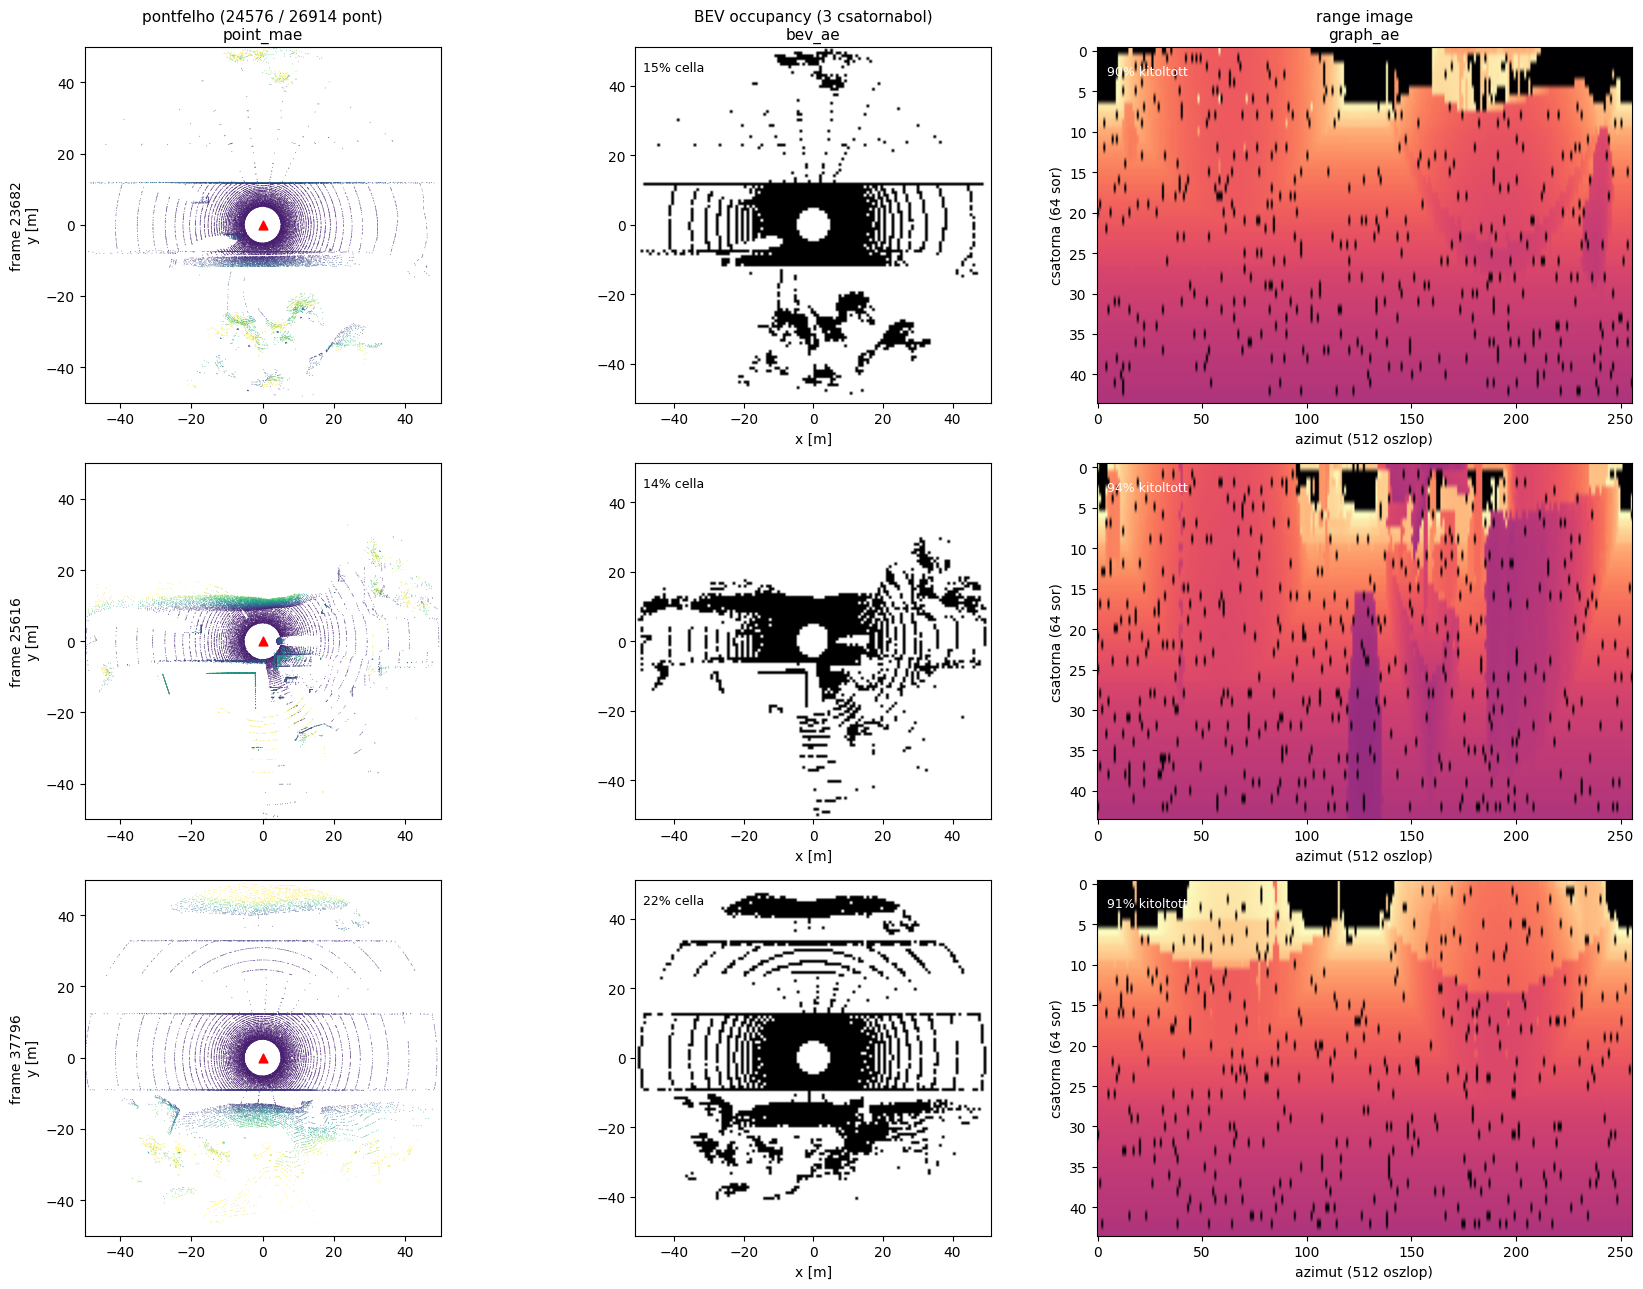

In [5]:
# Csak a megjelenitendo framek - nem a teljes adat.
SHOW_IDX = sorted(np.random.default_rng(1).choice(len(PATHS), 3, replace=False))
_show_raw = [np.load(PATHS[i]) for i in SHOW_IDX]
_show_pts = [torch.from_numpy(
    a[np.random.default_rng(i).choice(len(a), N_POINTS,
                                      replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(SHOW_IDX, _show_raw)]

# A BEV statisztika fix keplet, nem tanult jellemzoterkep - egy friss
# modellpeldany is a vegleges kepet adja.
_probe = BEVConvAE().eval()
print(f"BEV racs {_probe.grid_h}x{_probe.grid_w}, "
      f"{_probe.hparams.voxel_size} m cella   |   framek: {SHOW_IDX}")

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for row, (idx, raw, pts) in enumerate(zip(SHOW_IDX, _show_raw, _show_pts)):
    frame = pts.numpy()

    ax = axes[row, 0]
    ax.scatter(frame[:, 0], frame[:, 1], c=frame[:, 2], s=0.3, cmap="viridis",
               vmin=-3, vmax=4, linewidths=0)
    ax.scatter([0], [0], c="red", s=40, marker="^")
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    ax.set_ylabel(f"frame {idx}\ny [m]")
    if row == 0:
        ax.set_title(f"pontfelho ({len(frame)} / {len(raw)} pont)\npoint_mae",
                     fontsize=11)

    ax = axes[row, 1]
    with torch.no_grad():
        occ = _probe.to_bev(pts.unsqueeze(0))[0, 0].numpy()
    _r = _probe.hparams.pc_range          # a modell sajat hatosugara
    ax.imshow(occ, cmap="gray_r", origin="lower", extent=[-_r, _r, -_r, _r])
    ax.set_xlabel("x [m]")
    if row == 0:
        ax.set_title("BEV occupancy (3 csatornabol)\nbev_ae", fontsize=11)
    ax.text(0.02, 0.96, f"{100 * occ.mean():.0f}% cella", transform=ax.transAxes,
            fontsize=9, va="top")

    ax = axes[row, 2]
    ri = points_to_range_image(raw)[0]
    ax.imshow(ri, cmap="magma", aspect="auto", vmin=-1, vmax=1)
    ax.set_xlabel("azimut (512 oszlop)")
    ax.set_ylabel("csatorna (64 sor)")
    if row == 0:
        ax.set_title("range image\ngraph_ae", fontsize=11)
    ax.text(0.02, 0.95, f"{100 * (ri > -0.999).mean():.0f}% kitoltott",
            transform=ax.transAxes, color="white", fontsize=9, va="top")

plt.tight_layout()
plt.show()
free_vram(_probe)
drop("_show_raw")

### Interaktiv 3D nezet

Forgathato, nagyithato. Ez a NYERS pontfelho — amibol mindharom modell
bemenete keszul.

In [6]:
def show_3d(pts, title="", max_points=25000, size=1.2, extra=None,
            height=650):
    pts = pts.cpu().numpy() if hasattr(pts, "cpu") else np.asarray(pts)

    # Ritkitas, hogy a bongeszo ne akadjon meg.
    if len(pts) > max_points:
        sel = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts = pts[sel]

    traces = [go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=size, color=pts[:, 2], colorscale="Viridis",
                    cmin=-3, cmax=4, opacity=0.85,
                    colorbar=dict(title="z [m]", thickness=12, len=0.6)),
        name=f"pontfelho ({len(pts)})",
        hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>",
    )]

    # Az auto helye: a lidar az origoban van (x=0, z=2.4 a szenzor magassaga,
    # de a pontok mar a szenzorhoz kepest vannak megadva).
    traces.append(go.Scatter3d(
        x=[0], y=[0], z=[0], mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="ego (lidar)", hoverinfo="name"))

    for e_pts, e_name, e_color, e_size in (extra or []):
        e_pts = e_pts.cpu().numpy() if hasattr(e_pts, "cpu") else np.asarray(e_pts)
        traces.append(go.Scatter3d(
            x=e_pts[:, 0], y=e_pts[:, 1], z=e_pts[:, 2], mode="markers",
            marker=dict(size=e_size, color=e_color), name=e_name))

    fig = go.Figure(traces)
    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=0, r=0, t=40 if title else 0, b=0),
        legend=dict(x=0, y=1),
        scene=dict(
            # aspectmode="data": a harom tengely ARANYA a valos meretekbol
            # jon. Enelkul a plotly kockara nyujtja a jelenetet, es a lapos
            # ut-sik magasnak tunne.
            aspectmode="data",
            xaxis_title="x [m]  (elore)",
            yaxis_title="y [m]  (balra)",
            zaxis_title="z [m]  (fel)",
            # Kezdo kameraallas: kicsit hatulrol-felulrol, mint egy
            # kovetokamera - igy egybol felismerheto a jelenet.
            camera=dict(eye=dict(x=-1.4, y=-1.4, z=0.9)),
        ),
    )
    fig.show()

In [7]:
# Ugyanaz a harom frame 3D-ben, forgathatoan.
for idx, pts in zip(SHOW_IDX, _show_pts):
    show_3d(pts, title=f"frame {idx} - nyers pontfelho")

## 3. Kozos tanito fuggvenyek

A `train_model` **megszakithato es folytathato**: minden epoch vegen ment
(atomikusan, `.tmp` + atnevezes), es ujrainditaskor onnan folytatja, ahol
abbahagyta. Az optimizer allapota is mentodik — enelkul a folytatas nulla
lendulettel indulna, es az elso par epoch elrontana a tanulast.

In [8]:
def evaluate(model, data, batch, parts=False):
    """Atlagos loss a teljes adathalmazon.

    parts=True : (loss, dict) - a modell sajat diagnosztikaja is, atlagolva.
        EZ FONTOS: mindharom modellnel elofordult, hogy a loss szepen csokkent,
        kozben a modell mast tanult meg, mint amit akartunk:

          bev_ae     a loss 0.021-en allt, de az occupancy IoU csak 0.58 volt
                     (precision 0.59 - felmillio cella tevesen foglalt)
          point_mae  a Chamfer 4.74, a trivialis patch-atlag 4.79 -> a modell
                     KOLLAPSZALT, minden patch-re kb. ugyanazt adta. Az OK a
                     normalizalas hianya volt (lasd a 6. szakaszt); a modell
                     most a `gain_pct` diagnosztikat is visszaadja, ami pont
                     ezt a viszonyt meri epochonkent.
          graph_ae   az L1 nagy reszet az URES teruletek tettek ki

        Egyetlen szambol ezek egyike sem latszik.
    """
    model.eval()
    total, n, acc = 0.0, 0, {}
    with torch.no_grad():
        for i in range(0, len(data), batch):
            xb = data[i:i + batch].to(DEVICE, non_blocking=True).float()
            if parts:
                loss, p = model.loss(xb, parts=True)
                for k, v in p.items():
                    acc[k] = acc.get(k, 0.0) + v * len(xb)
            else:
                loss = model.loss(xb)
            total += float(loss) * len(xb)
            n += len(xb)
    if not parts:
        return total / n
    return total / n, {k: v / n for k, v in acc.items()}


def train_model(model, label, batch, train_data, val_data,
                epochs=EPOCHS, lr=1e-3, patience=5, sched="plateau",
                resume=True, clip=5.0, warmup_frac=0.0):
    """`warmup_frac`: az ELSO epoch hany szazalekaban fusson fel az LR nullarol.

    TRANSFORMERNEL EZ KELL. A cosine/plateau scheduler epoch-szintu, vagyis az
    elso epoch TELJES egeszeben a maximalis LR-en fut - pont akkor, amikor a
    LayerNorm-ok, a mask_token es az attention sulyai meg semmilyen ertelmes
    allapotban nincsenek. A point_mae gradiens-normaja az elso lepeseknel
    merve 13-30 kozott van, a clip=5.0 pedig ezt levagja: a lepes IRANYA igy
    a veletlen kezdeti allapotbol jon, a HOSSZA meg maximalis.

    A warmup lepes-szintu (a batch-eken belul is valtozik), ezert nem lehet a
    meglevo epoch-szintu scheduler resze - a kettot egymas melle tesszuk: a
    warmup alatt a warmup hatarozza meg az LR-t, utana a scheduler.
    """
    model = model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    if sched == "plateau":
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=2, min_lr=lr / 100)
    elif sched == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=lr / 100)
    else:
        sched = None

    # Hany OPTIMIZER-LEPESEN at tart a felfutas (nem epoch, hanem lepes).
    steps_per_epoch = (len(train_data) + batch - 1) // batch
    warmup_steps = int(warmup_frac * steps_per_epoch)

    hist = {"label": label, "arch": type(model).__name__,
            "train": [], "val": [], "best": float("inf"),
            "params": sum(p.numel() for p in model.parameters()),
            "ckpt": f"lidar/{label}.ckpt"}
    best_state, bad, start_ep = None, 0, 1

    # --- FOLYTATAS a mentett checkpointbol -----------------------------
    if resume and os.path.exists(hist["ckpt"]):
        ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
        # Csak akkor folytatunk, ha UGYANARROL a modellrol van szo. Ha kozben
        # atirtad az architekturat, a sulyok alakja nem egyezne - olyankor
        # inkabb elolrol kezdunk, mint hogy hibaval elszalljon.
        if ck.get("arch") == hist["arch"] and "epoch" in ck:
            try:
                model.load_state_dict(ck["state_dict"])
                opt.load_state_dict(ck["optimizer"])
                if sched is not None and ck.get("sched") is not None:
                    sched.load_state_dict(ck["sched"])
                hist["train"] = list(ck.get("train", []))
                hist["val"] = list(ck.get("val", []))
                hist["best"] = ck.get("best_val", float("inf"))
                best_state = ck.get("best_state", ck["state_dict"])
                bad = ck.get("bad", 0)
                start_ep = ck["epoch"] + 1
                if start_ep > epochs:
                    print(f"{label}: mar lefutott {ck['epoch']} epoch "
                          f"(best val {hist['best']:.5f}). Emeld az `epochs` "
                          f"erteket, vagy add at a resume=False-t az "
                          f"ujrakezdeshez.")
                    model.load_state_dict(best_state)
                    hist["epochs_run"] = len(hist["train"])
                    hist["time"] = 0.0
                    return hist, model
                print(f"{label}: FOLYTATAS a {ck['epoch']}. epoch utan "
                      f"(best val {hist['best']:.5f})")
            except (RuntimeError, KeyError) as e:
                print(f"{label}: a checkpoint nem illeszkedik ({type(e).__name__}), "
                      f"elolrol kezdjuk")
                best_state, bad, start_ep = None, 0, 1
                hist["train"], hist["val"], hist["best"] = [], [], float("inf")
        else:
            print(f"{label}: regi formatumu vagy mas architekturaju checkpoint, "
                  f"elolrol kezdjuk")

    print(f"{label}  ({hist['params'] / 1e6:.1f}M parameter, lr={lr}, "
          f"batch={batch}, {len(train_data)} train frame, "
          f"epoch {start_ep}-{epochs})")
    t0 = time.time()

    for ep in range(start_ep, epochs + 1):
        model.train()
        run, n = 0.0, 0
        perm = torch.randperm(len(train_data))
        bar = tqdm(range(0, len(train_data), batch), desc=f"epoch {ep}/{epochs}",
                   leave=False)
        for step, i in enumerate(bar):
            # A warmup CSAK az elso epochban, es csak a `warmup_steps` alatt
            # nyul az LR-hez. A felfutas VEGEN vissza kell allitani a teljes
            # LR-re: a scheduler a sajat belso szamlalojabol dolgozik, es nem
            # tud rola, hogy kozben kezzel allitgattuk - ha itt nem allitjuk
            # vissza, az LR a warmup utolso ertekere (lr/warmup_steps) ragad,
            # es a modell vegig ~27x kisebb LR-rel tanulna.
            if warmup_steps and ep == 1 and step <= warmup_steps:
                w = min(step + 1, warmup_steps) / warmup_steps
                for g in opt.param_groups:
                    g["lr"] = lr * w
            xb = train_data[perm[i:i + batch]].to(DEVICE, non_blocking=True).float()
            loss = model.loss(xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            # A vagas 1.0 volt, de merve a point_mae gradiense 96-100%-ban
            # e FOLOTT volt (atlag 2.1-4.4) - vagyis szinte minden lepesben
            # vagtunk. 5.0-nal maradunk, de NEM azert, amiert korabban ide
            # volt irva ("mar csak a valodi kiugrasokat fogja meg") - az nem
            # igaz. A point_mae 8 rezidualis blokkjan (6 encoder + 2 decoder)
            # a gradiens osszeadodik, ezert a MEDIANJA is 8.28, a kuszob
            # folott: a lepesek 77%-a vagva van, nem a kiugrasok.
            #
            # MERVE (300 lepes, lr=2e-3, warmup 5%) - a lazabb vagas ROSSZABB:
            #
            #     clip   vagva   gain     cd_m2
            #       5     77%   +71.6%    3.640   <- ez
            #      10     36%   +71.1%    3.763
            #      20     10%   +70.8%    3.843
            #    nincs     0%   +68.2%    4.048
            #
            # Vagyis a vagas itt NEM biztonsagi fek, hanem a tanulas resze:
            # egyfajta normalizalt lepeskoz (a lepes iranya a gradiensbol jon,
            # a hossza fixen 5.0). Ezert nem szabad "kijavitani" lazabbra.
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            run += float(loss.detach()) * len(xb)
            n += len(xb)
            bar.set_postfix(loss=f"{float(loss.detach()):.5f}")



        tr = run / n
        va, diag = evaluate(model, val_data, batch, parts=True)

        TRACK = {"LidarAE": "l1_occupied"}       # modell -> diagnosztika-kulcs
        key = TRACK.get(hist["arch"])
        score = diag[key] if key and key in diag else va

        if sched is not None:
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(score)
            else:
                sched.step()
        hist["train"].append(tr)
        hist["val"].append(va)
        hist.setdefault("diag", []).append(diag)
        hist.setdefault("lr", []).append(opt.param_groups[0]["lr"])

        # Early stopping: ha `patience` epochon at nem javul, megallunk.
        improved = score < hist["best"]
        if improved:
            hist["best"], bad = score, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1

        # MENTES MINDEN EPOCH VEGEN - ez teszi folytathatova a futast.
        # Eloszor egy .tmp fajlba irunk, aztan atnevezzuk: igy ha pont mentes
        # kozben szakad meg a futas, a regi checkpoint epen marad.
        tmp = hist["ckpt"] + ".tmp"
        torch.save({"state_dict": {k: v.detach().cpu()
                                   for k, v in model.state_dict().items()},
                    "best_state": best_state,
                    "optimizer": opt.state_dict(),
                    "sched": sched.state_dict() if sched is not None else None,
                    "epoch": ep,
                    "bad": bad,
                    "hparams": (dict(model.hparams) if hasattr(model, "hparams")
                                else {}),
                    "arch": hist["arch"],
                    "best_val": hist["best"],
                    "train": hist["train"], "val": hist["val"],
                    # A diagnosztika is menjen bele: a nyers loss onmagaban
                    # ertelmezhetetlen (mas patch-eles/sulyozas mellett mas a
                    # skalaja), a gain_pct viszont osszehasonlithato.
                    "diag": hist.get("diag", []),
                    "lr": hist.get("lr", [])}, tmp)
        os.replace(tmp, hist["ckpt"])

        # A diagnosztika a loss MELLE - abbol latszik, hogy a modell
        # tenyleg azt tanulja-e, amit akarunk (lasd evaluate docstring).
        extra = "  ".join(f"{k} {v:.3f}" for k, v in diag.items()
                          if k in ("occ_prec", "occ_rec", "z_mae_m", "spread_ratio",
                                   "l1_occupied", "l1_empty", "gain_pct",
                                   "cd_m2"))
        # Az aktualis LR is latszodjon - enelkul nem ellenorizheto, hogy a
        # scheduler tenyleg dolgozik-e.
        extra += f"  lr {opt.param_groups[0]['lr']:.2e}"
        print(f"  epoch {ep:2d}  train {tr:.5f}  val {va:.5f}"
              f"{'   ' + extra if extra else ''}"
              f"  [{(time.time() - t0) / 60:.0f} perc]"
              f"{'  *' if improved else ''}")

        if bad >= patience:
            print(f"  early stop ({patience} epoch javulas nelkul)")
            break

    # A LEGJOBB sulyokat adjuk vissza, nem az utolsokat.
    model.load_state_dict(best_state)
    hist["epochs_run"] = len(hist["train"])
    hist["time"] = time.time() - t0

    print(f"  kesz: {hist['ckpt']}  (best val {hist['best']:.5f}, "
          f"{hist['time'] / 60:.1f} perc ebben a futasban)")
    return hist, model


def plot_history(hist, ylabel="loss"):
    """Egy modell tanulasi gorbeje, a learning rate-tel egyutt.

    Az LR a masodik y-tengelyen: igy latszik, hogy a gorbe ellaposodasa a
    konvergencia jele-e, vagy csak az LR csokkent le.
    """
    ep = range(1, len(hist["train"]) + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ep, hist["train"], "-o", ms=3, label="train")
    ax.plot(ep, hist["val"], "-s", ms=3, label="val")
    ax.axhline(hist["best"], ls=":", c="gray",
               label=f"best val {hist['best']:.5f}")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    if hist.get("lr"):
        ax2 = ax.twinx()
        ax2.plot(ep, hist["lr"], "-", c="tab:green", alpha=0.5, lw=1.2,
                 label="learning rate")
        ax2.set_ylabel("learning rate", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")
        ax2.set_yscale("log")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
    else:
        ax.legend()

    ax.set_title(f"{hist['label']}  ({hist['params'] / 1e6:.1f}M parameter)")
    plt.tight_layout()
    plt.show()

## 4. `bev_ae` — fix BEV statisztika + konvolucios AE

A pontfelho felulnezeti racsra kerul (128x128, 0.8 m cella), cellankent
**harom fix** csatornaval: occupancy, z_max, z_min. Erre megy egy konvolucios
autoencoder.

**Ket dolgot kellett javitani, mindkettot MERES alapjan.**

**1. A loss.** A regi valtozat mind az ot csatornat egyetlen sulyozott MSE-be
tette, es ez elrejtette a valodi problemat: a loss 0.021-en allt, de az
occupancy IoU csak 0.58 volt. Ket oka volt - a z-csatornak ures cellaban
0-t kapnak, a dekoder Sigmoid-ja viszont sosem ad pontos 0-t (le nem vihato
loss-padlo), es az occupancy 0/1 cimkejen az MSE gradiense elhal (a kimeneti
retegen 0.00089 vs BCE-vel 0.0528). Most a magassagok **maszkolva** vannak a
valodi occupancy-val, az occupancy pedig **BCE + Dice** taggal tanul.

**2. A szuk keresztmetszet.** Ez volt a nagyobb nyereseg. A latenst korabban
egy `Linear` par allitotta elo (16384 -> 256, 4.2M parameter), ami a BEV
terbeli szerkezetet egyetlen lapos szorzasba nyomta:

| szukites | IoU | precision | z_mae | param |
|---|---|---|---|---|
| Linear-par | 0.562 | 0.766 | — | 9.8M |
| **conv-neck** | **0.643** | **0.804** | **0.141 m** | **2.8M** |
| nincs bottleneck | 0.895 | 0.941 | — | 1.4M |

A "nincs bottleneck" sor a felso korlat - az a latens 16384 ertek, amit az RL
observation nem tud kezelni. A conv-neck ennek a felso korlatnak a fele utjat
megteszi, harmadannyi parameterbol, mint a Linear-par.

**Csatornak.** A `density` es a `z_mean` kiesett: kimerve az elhagyasuk
gyakorlatilag ingyen van (IoU 0.652 -> 0.643). A `z_mean` a masik ketto
kozott van, a `density`-t pedig az occupancy mar lefedi. A `z_max`+`z_min`
viszont KELL: csak `z_max`-szal a magassaghiba visszaromlik, mert egy
jardaszegely es egy auto nem ugyanaz.


train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

train (35037, 24576, 3)  val (7507, 24576, 3)  12.5 GB
bev_ae: mar lefutott 35 epoch (best val 0.07277). Emeld az `epochs` erteket, vagy add at a resume=False-t az ujrakezdeshez.


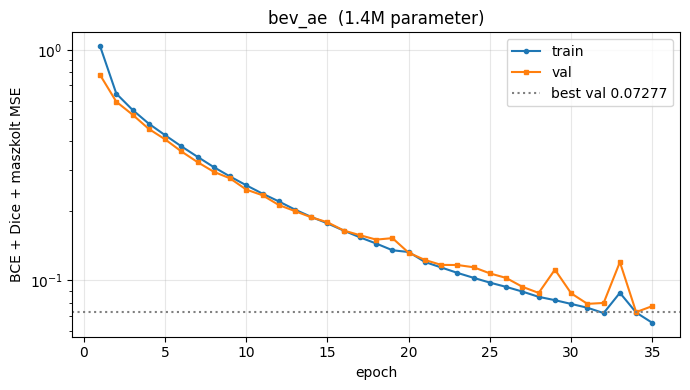

In [9]:
# A pontfelho-alapu modellek adata. A range image-eket NEM toltjuk be melle -
# egyutt nem fernenek a RAM-ba. A TEST halmazt sem: azt csak a legvegen nezzuk.
x_train, x_val = load_clouds(("train", "val"))
print(f"train {tuple(x_train.shape)}  val {tuple(x_val.shape)}  "
      f"{(x_train.numel() + x_val.numel()) * 4 / 1e9:.1f} GB")

model = BEVConvAE()
hist_bev_ae, model = train_model(
    model, label="bev_ae", batch=BATCH["bev_ae"],
    train_data=x_train, val_data=x_val, epochs=EPOCHS, lr=1e-3)
plot_history(hist_bev_ae, ylabel="BCE + Dice + maszkolt MSE")

In [10]:
free_vram(model)
print("bev_ae utan:", vram())
print("(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)")

bev_ae utan: 0.00 GB foglalt / 0.00 GB fenntartva / 8.3 GB osszes
(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)


## 5. `graph_ae` — range image + dinamikus graf

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

ranges  train (35037, 1, 44, 256)  val (7507, 1, 44, 256)  1.9 GB
graph_ae: mar lefutott 30 epoch (best val 0.02094). Emeld az `epochs` erteket, vagy add at a resume=False-t az ujrakezdeshez.


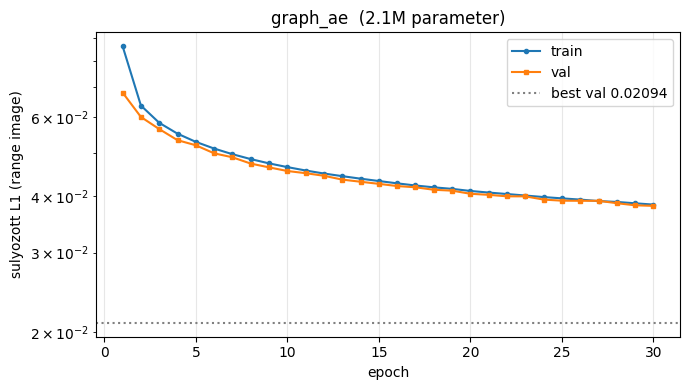

In [11]:
# A pontfelhoket eldobjuk, hogy a range image-eknek legyen helye.
drop("x_train", "x_val")
r_train, r_val = load_ranges(("train", "val"))
print(f"ranges  train {tuple(r_train.shape)}  val {tuple(r_val.shape)}  "
      f"{(r_train.numel() + r_val.numel()) * 4 / 1e9:.1f} GB")
GRAPH_LR = 4.5e-6

model = LidarAE(DDCONFIG)
hist_graph_ae, model = train_model(
    model, label="graph_ae", batch=BATCH["graph_ae"],
    train_data=r_train, val_data=r_val, epochs=EPOCHS, lr=GRAPH_LR)
plot_history(hist_graph_ae, ylabel="sulyozott L1 (range image)")


In [12]:
free_vram(model)
print("graph_ae utan:", vram())

graph_ae utan: 0.00 GB foglalt / 0.00 GB fenntartva / 8.3 GB osszes


## 6. `point_mae` — maszkolt autoencoder

In [13]:
# Vissza a pontfelhokre.
drop("r_train", "r_val")
x_train, x_val = load_clouds(("train", "val"))

model = PointMAE()
hist_point_mae, model = train_model(
    model, label="point_mae", batch=BATCH["point_mae"],
    train_data=x_train, val_data=x_val, epochs=60, lr=2e-3,
    sched="cosine", resume=True, warmup_frac=0.05)
plot_history(hist_point_mae, ylabel="Chamfer")

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

point_mae: FOLYTATAS a 22. epoch utan (best val 0.92813)
point_mae  (4.0M parameter, lr=0.002, batch=64, 35037 train frame, epoch 23-60)


epoch 23/60:   0%|          | 0/548 [00:00<?, ?it/s]

  epoch 23  train 0.92071  val 0.92895   spread_ratio 0.381  cd_m2 1.426  gain_pct 89.213  lr 1.36e-03  [6 perc]


...

  epoch 36  train 0.83818  val 0.85026   spread_ratio 0.378  cd_m2 1.326  gain_pct 90.130  lr 7.04e-04  [84 perc]  *


epoch 37/60:   0%|          | 0/548 [00:00<?, ?it/s]

  epoch 37  train 0.83499  val 0.84441   spread_ratio 0.376  cd_m2 1.322  gain_pct 90.188  lr 6.55e-04  [90 perc]  *


epoch 38/60:   0%|          | 0/548 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
free_vram(model)
print("point_mae utan:", vram())

## 7. Osszehasonlitas

In [ ]:
import inspect


def load_model(hist):
    ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
    arch = ck["arch"]
    cls = {"PointMAE": PointMAE, "BEVConvAE": BEVConvAE}.get(arch)

    if cls is None:                      # LidarAE - a ddconfig kivulrol jon
        m = LidarAE(DDCONFIG)
    else:
        ok = set(inspect.signature(cls.__init__).parameters)
        hp = {k: v for k, v in (ck.get("hparams") or {}).items() if k in ok}
        m = cls(**hp)

    m.load_state_dict(ck.get("best_state") or ck["state_dict"])
    return m.eval()


print("load_model() kesz - a 7.x cellak ezt hasznaljak")


In [ ]:
# --- 7.1  Az osszehasonlitashoz szukseges adat ---
#
# Csak a VAL es a TEST halmaz kell. A TEST itt kerul eloszor elo: a tanitas
# alatt egyetlen modell sem latta, es egyetlen dontesunk sem tamaszkodott ra.
drop("x_train", "x_val", "r_train", "r_val")
x_val, x_test = load_clouds(("val", "test"))
r_val, r_test = load_ranges(("val", "test"))

HISTORIES = [hist_bev_ae, hist_graph_ae, hist_point_mae]
LABELS = [h["label"] for h in HISTORIES]

# Melyik modell melyik reprezentaciobol dolgozik. Ugyanazok a framek, kozos
# permutacioval vagva - tehat az osszehasonlitas ervenyes.
VAL_DATA = {"bev_ae": x_val, "graph_ae": r_val, "point_mae": x_val}
TEST_DATA = {"bev_ae": x_test, "graph_ae": r_test, "point_mae": x_test}

# A loss mertekegysege - a 'val loss' oszlop NEM hasonlithato a sorok kozott.
UNITS = {"bev_ae": "BCE+Dice+MSE", "graph_ae": "sulyozott L1",
         "point_mae": "Chamfer [m^2]"}

# Eval batch: nagyobb lehet a tanitasinal, mert csak no_grad inferencia fut.
EVAL_BATCH = {"bev_ae": 512, "graph_ae": 32, "point_mae": 256}

print(f"x_val {tuple(x_val.shape)}  x_test {tuple(x_test.shape)}")
print(f"r_val {tuple(r_val.shape)}  r_test {tuple(r_test.shape)}")
print(f"osszesen {(x_val.numel() + x_test.numel() + r_val.numel() + r_test.numel()) * 4 / 1e9:.1f} GB\n")

print("Mentett checkpointok:")
for h in HISTORIES:
    print(f"  {h['ckpt']:26s} {os.path.getsize(h['ckpt']) / 1e6:6.1f} MB   "
          f"best {h['best']:.5f}  ({h['epochs_run']} epoch, {h['time'] / 60:.0f} perc)")


In [ ]:
# --- 7.1b  A latens tenyleges alakja - MERVE, nem beirva ---
#
# Korabban egy kezzel karbantartott LATENT_SHAPE dict allt itt; az elavult, es
# a cella NameError-ral elszallt. Most magatol a modelltol kerdezzuk meg.

LATENT_SHAPE, LATENT_SIZE = {}, {}
probe = {}
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    xb = VAL_DATA[h["label"]][:2].to(DEVICE).float()
    with torch.no_grad():
        z = m.encode(xb)
    LATENT_SHAPE[h["label"]] = tuple(z.shape[1:])
    LATENT_SIZE[h["label"]] = int(np.prod(z.shape[1:]))
    probe[h["label"]] = (float(z.min()), float(z.max()), float(z.std()))
    free_vram(m)

# A bemenet merete, hogy latszodjon a TOMORITES aranya.
IN_SIZE = {"bev_ae": N_POINTS * 3, "point_mae": N_POINTS * 3,
           "graph_ae": int(np.prod(r_val.shape[1:]))}

print(f"{'modell':12s} {'latens alak':>16s} {'ertek':>8s} {'bemenet':>9s} "
      f"{'tomorites':>10s} {'min':>7s} {'max':>7s} {'std':>6s}")
print("-" * 82)
for lab in LABELS:
    lo, hi, sd = probe[lab]
    print(f"{lab:12s} {str(LATENT_SHAPE[lab]):>16s} {LATENT_SIZE[lab]:8d} "
          f"{IN_SIZE[lab]:9d} {LATENT_SIZE[lab] / IN_SIZE[lab]:9.2f}x "
          f"{lo:7.2f} {hi:7.2f} {sd:6.2f}")

print("\nA latens mindharomnal TERBELI/strukturalt, nem lapitott vektor.")
print("A 'tomorites' a latens es a bemenet ertekszamanak aranya.")
print("A min/max/std azt mutatja, egy nagysagrendben van-e a tobbi obs-jellel")
print("(a kamera latense tanh*4 miatt -4..4).")


In [ ]:
# --- 7.2  Altalanositas: val vs test ---
#
# A val loss-t a tanitas alatt vegig neztuk, es az alapjan valasztottuk a
# legjobb epochot - abba mar "belelattunk". A testet most nezzuk eloszor.
#
# Mindket oszlop a TELJES lossal merve, UGYANAZON a modellen - kulonben ket
# kulonbozo mennyiseget hasonlitananak ossze.

val_scores, test_scores = {}, {}
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    eb = EVAL_BATCH[h["label"]]
    val_scores[h["label"]] = evaluate(m, VAL_DATA[h["label"]], eb)
    test_scores[h["label"]] = evaluate(m, TEST_DATA[h["label"]], eb)
    free_vram(m)

print(f"{'modell':12s} {'mertekegyseg':>16s} {'val':>10s} {'test':>10s} {'elteres':>9s}")
print("-" * 62)
for lab in LABELS:
    va, te = val_scores[lab], test_scores[lab]
    print(f"{lab:12s} {UNITS[lab]:>16s} {va:10.5f} {te:10.5f} "
          f"{100 * (te - va) / va:+8.1f}%")

print("\nA sorok kozott az abszolut ertek NEM osszemerheto (mas loss).")
print("Az 'elteres' viszont igen: az a TULTANULAS merteke.")
print("  |elteres| < 5%   : rendben, altalanosit")
print("  elteres > 15%    : a val halmazra valasztottunk tul szorosan")


In [ ]:
# --- 7.3  VERI-E A TRIVIALIS MEGOLDAST? ---
#
# EZ A LEGFONTOSABB CELLA. Egy loss-ertek onmagaban ertelmezhetetlen: tudni
# kell, mit er ugyanazon az adaton egy olyan "modell", ami semmit nem tanult.
#
# Modellenkent mas a trivialis megoldas, ezert mindegyiknek sajat baseline-ja
# van. A 'nyereseg' oszlop a lenyeg: hany szazalekkal jobb a modell annal,
# mint amit tanulas NELKUL is el lehetne erni.

import torch.nn.functional as F

BASE_N = 512          # ennyi frame-en merunk (eleg a stabil atlaghoz)
rows = []

# ---- point_mae: Chamfer a maszkolt patch-eken ----------------------------
m = load_model(hist_point_mae).to(DEVICE)
from lidar.point_mae import chamfer_distance
cds, bases, glob_b = [], [], []
torch.manual_seed(0)
with torch.no_grad():
    for i in tqdm(range(0, BASE_N, 64), desc="point_mae", leave=False):
        xb = x_val[i:i + 64].to(DEVICE).float()
        reb, gt, _, _ = m(xb)
        B, M, K, _ = reb.shape
        g = gt.reshape(B * M, K, 3)
        cds.append(float(chamfer_distance(reb.reshape(B * M, K, 3), g)))
        # trivialis 1: minden patch-re a SAJAT atlagat josolni
        bases.append(float(chamfer_distance(
            gt.mean(2, keepdim=True).expand_as(gt).reshape(B * M, K, 3), g)))
        # trivialis 2: MINDEN patch-re ugyanazt az atlagos alakot -> kollapszus-teszt
        ms = reb.reshape(B * M, K * 3).mean(0)
        glob_b.append(float(chamfer_distance(
            ms.reshape(1, K, 3).expand(B * M, K, 3).contiguous(), g)))
free_vram(m)
cd, base, gb = np.mean(cds), np.mean(bases), np.mean(glob_b)
rows.append(("point_mae", "Chamfer [m^2]", cd, "patch-atlag", base,
             100 * (1 - cd / base)))
print(f"point_mae kollapszus-teszt: sajat joslat {cd:.3f} vs a sajat GLOBALIS "
      f"atlagos alakja {gb:.3f}")
print(f"  -> a joslat {100 * (1 - cd / gb):.0f}%-kal jobb. Ha ez ~0%, a modell "
      f"minden patch-re ugyanazt adja (KOLLAPSZUS).\n")

# ---- bev_ae: occupancy IoU / precision / recall --------------------------
m = load_model(hist_bev_ae).to(DEVICE)
tp = fp = fn = 0.0
occ_sum = occ_n = 0.0
with torch.no_grad():
    for i in tqdm(range(0, BASE_N, 128), desc="bev_ae", leave=False):
        xb = x_val[i:i + 128].to(DEVICE).float()
        bev = m.to_bev(xb)
        rec = m.decode(m.encode_bev(bev))
        t = bev[:, 0] > 0.5
        p = rec[:, 0] > 0.5
        tp += float((p & t).sum()); fp += float((p & ~t).sum()); fn += float((~p & t).sum())
        occ_sum += float(t.float().sum()); occ_n += t.numel()
free_vram(m)
prec = tp / max(tp + fp, 1); rec_ = tp / max(tp + fn, 1)
iou = tp / max(tp + fp + fn, 1)
prior = occ_sum / occ_n            # a cellak hany szazaleka foglalt
# trivialis: "minden cella ures" -> IoU 0 ; "minden cella foglalt" -> IoU = prior
rows.append(("bev_ae", "occupancy IoU", iou, "mindent foglaltnak jsol", prior,
             100 * (1 - prior / iou) if iou > 0 else float("nan")))
print(f"bev_ae occupancy: precision {prec:.3f}  recall {rec_:.3f}  IoU {iou:.3f}")
print(f"  a cellak {100 * prior:.1f}%-a foglalt -> a 'mindent foglalt' IoU-ja {prior:.3f}\n")

# ---- graph_ae: L1 a range image-en --------------------------------------
m = load_model(hist_graph_ae).to(DEVICE)
l1s, base_l1 = [], []
with torch.no_grad():
    for i in tqdm(range(0, min(BASE_N, len(r_val)), 32), desc="graph_ae", leave=False):
        xb = r_val[i:i + 32].to(DEVICE).float()
        out = m(xb)
        l1s.append(float(F.l1_loss(out, xb)))
        # trivialis: a kep ATLAGAT josolni mindenhova
        base_l1.append(float(F.l1_loss(xb.mean(dim=(2, 3), keepdim=True).expand_as(xb), xb)))
free_vram(m)
l1, bl1 = np.mean(l1s), np.mean(base_l1)
rows.append(("graph_ae", "L1 (range)", l1, "kep-atlag", bl1, 100 * (1 - l1 / bl1)))

# ---- osszefoglalo --------------------------------------------------------
print(f"\n{'modell':12s} {'metrika':>15s} {'modell':>9s} {'trivialis':>24s} "
      f"{'baseline':>9s} {'nyereseg':>9s}")
print("-" * 84)
for lab, met, val, bname, bval, gain in rows:
    print(f"{lab:12s} {met:>15s} {val:9.3f} {bname:>24s} {bval:9.3f} {gain:+8.1f}%")

print("\nA 'nyereseg' a lenyeg: ennyivel jobb a modell annal, amit tanulas")
print("NELKUL is el lehetne erni. A bev_ae-nel a nagyobb IoU a jobb, a masik")
print("kettonel a kisebb loss - a nyereseg mindharomnal 'minel nagyobb, annal jobb'.")


In [ ]:
# --- 7.4  point_mae: mit epit vissza? ---
#
# A modell a MASZKOLT patch-eket rekonstrualja. Kek: a lathato patch-ek
# kozeppontjai (ezeket latta az encoder). Piros: a visszaepitett hianyzo
# pontok. Zold: a valodi pontok ugyanazokon a helyeken.

n = 3
vidx = np.random.default_rng(0).choice(len(x_val), n, replace=False)
sample = x_val[vidx]

m = load_model(hist_point_mae).to(DEVICE)
torch.manual_seed(0)
with torch.no_grad():
    rebuild, gt, mask, center = m(sample.to(DEVICE))
# A modell NORMALIZALT terben dolgozik (a patch a sajat meretere, a kozeppont
# a hatosugarra osztva). A rajzolashoz METER kell, kulonben a pontok a valodi
# jelenet 1/50-ed reszen zsufolodnanak ossze.
rebuild = m.denorm_patches(rebuild)
gt = m.denorm_patches(gt)
center = m.denorm_centers(center)
free_vram(m)
rebuild, gt, mask, center = (t.cpu() for t in (rebuild, gt, mask, center))

fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.8))
for j in range(n):
    vis_c = center[j][~mask[j]]
    mask_c = center[j][mask[j]]
    # A patch-ek lokalis koordinatait vissza kell tolni a kozeppontjukra.
    rec_pts = (rebuild[j] + mask_c.unsqueeze(1)).reshape(-1, 3)
    gt_pts = (gt[j] + mask_c.unsqueeze(1)).reshape(-1, 3)

    ax = axes[j]
    ax.scatter(sample[j][:, 0], sample[j][:, 1], s=0.2, c="lightgray",
               linewidths=0, label="teljes felho")
    ax.scatter(gt_pts[:, 0], gt_pts[:, 1], s=2.0, c="limegreen", linewidths=0,
               label="valodi (maszkolt)")
    ax.scatter(rec_pts[:, 0], rec_pts[:, 1], s=2.0, c="tab:red", linewidths=0,
               label=f"rekonstrualt ({len(mask_c)} patch)")
    ax.scatter(vis_c[:, 0], vis_c[:, 1], s=28, c="royalblue", marker="o",
               linewidths=0, label=f"lathato kozeppont ({len(vis_c)})")
    ax.set_xlim(-52, 52); ax.set_ylim(-52, 52); ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    if j == 0:
        ax.set_ylabel("y [m]")
        ax.legend(fontsize=8, loc="upper right", markerscale=2)
    # Patch-enkenti Chamfer, hogy szam is legyen a kep mellett.
    from lidar.point_mae import chamfer_distance
    K = rebuild.shape[2]
    cdj = float(chamfer_distance(rebuild[j].reshape(-1, K, 3), gt[j].reshape(-1, K, 3)))
    ax.set_title(f"point_mae #{j}   Chamfer {cdj:.3f} m^2", fontsize=10)

plt.tight_layout()
plt.show()

print("Amit nezni kell: a piros pontok a zoldek KOZELEBEN vannak-e, es")
print("kovetik-e az utca/jarmu kontúrjat. Ha a pirosak egy kupacba tomorulnek")
print("a patch-kozeppontok korul, a modell csak az atlagot tanulta meg.")


In [ ]:
# --- 7.5  Ugyanaz 3D-ben, interaktivan ---
#
# A felulnezeten nem latszik, hogy a rekonstrualt pontok a helyes MAGASSAGBAN
# vannak-e. Itt korbe lehet jarni: ha a piros pontok a szurke felho felszinen
# ulnek, a modell megtanulta a geometriat; ha a levegoben lebegnek vagy a
# foldbe fulnak, nem.

j = 0                                     # melyik mintat nezzuk a harombol
mask_c_j = center[j][mask[j]]
rec_pts_j = (rebuild[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)
gt_pts_j = (gt[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)

show_3d(
    sample[j],
    title=f"point_mae rekonstrukcio 3D  -  {len(mask_c_j)} maszkolt patch",
    extra=[
        (gt_pts_j, "valodi (maszkolt) pontok", "limegreen", 2.0),
        (rec_pts_j, "rekonstrualt pontok", "red", 2.0),
        (center[j][~mask[j]], "lathato patch-kozeppontok", "royalblue", 4.0),
    ],
)


In [ ]:
# --- 7.6  bev_ae es graph_ae rekonstrukcio ---

# ---- bev_ae: occupancy terkep --------------------------------------------
m = load_model(hist_bev_ae).to(DEVICE)
_r = m.hparams.pc_range
EXT = [-_r, _r, -_r, _r]
with torch.no_grad():
    bev = m.to_bev(sample.to(DEVICE))
    rec = m.decode(m.encode_bev(bev))
bev, rec = bev.cpu(), rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2, n, figsize=(5 * n, 9.2))
for j in range(n):
    axes[0, j].imshow(bev[j, 0], cmap="gray_r", origin="lower", vmin=0, vmax=1, extent=EXT)
    axes[0, j].set_title(f"bev_ae eredeti occupancy #{j}", fontsize=10)
    axes[1, j].imshow(rec[j, 0], cmap="gray_r", origin="lower", vmin=0, vmax=1, extent=EXT)
    t = bev[j, 0] > 0.5
    p = rec[j, 0] > 0.5
    iou_j = float((p & t).sum()) / max(float((p | t).sum()), 1)
    axes[1, j].set_title(f"rekonstrukcio  (IoU {iou_j:.3f})", fontsize=10)
    for i in (0, 1):
        axes[i, j].set_xlabel("x [m]")
axes[0, 0].set_ylabel("y [m]"); axes[1, 0].set_ylabel("y [m]")
plt.tight_layout(); plt.show()

# CSATORNANKENTI COLLAPSE-FIGYELO: ha a 'rec std' nagysagrendekkel a 'cel std'
# alatt van, a halo az adott csatornat KIATLAGOLTA (konstanst josol).
print(f"{'csatorna':12s} {'cel std':>9s} {'rec std':>9s} {'arany':>7s} {'MSE':>9s}")
print("-" * 50)
for c, name in enumerate(["occupancy", "z_max", "z_min"][:bev.shape[1]]):
    cs, rs = float(bev[:, c].std()), float(rec[:, c].std())
    print(f"{name:12s} {cs:9.4f} {rs:9.4f} {rs / max(cs, 1e-9):7.2f} "
          f"{float(F.mse_loss(rec[:, c], bev[:, c])):9.5f}")
print("Az 'arany' 1.0 korul egeszseges; 0 fele a csatorna kiatlagolodott.")

# ---- graph_ae: range image -----------------------------------------------
m = load_model(hist_graph_ae).to(DEVICE)
ri_in = r_val[vidx].to(DEVICE).float()
with torch.no_grad():                       # framenkent: a dekoder memoriaigenyes
    ri_rec = torch.cat([m(ri_in[i:i + 1]) for i in range(len(ri_in))])
ri_in, ri_rec = ri_in.cpu(), ri_rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2 * n, 1, figsize=(14, 2.4 * 2 * n))
for j in range(n):
    axes[2 * j].imshow(ri_in[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j].set_title(
        f"graph_ae eredeti range image #{j}  "
        f"(kitoltottseg {(ri_in[j] > -0.999).float().mean() * 100:.1f}%)", fontsize=10)
    axes[2 * j].set_ylabel("csatorna")
    axes[2 * j + 1].imshow(ri_rec[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j + 1].set_title(
        f"rekonstrukcio  (L1 {F.l1_loss(ri_rec[j], ri_in[j]):.4f})", fontsize=10)
    axes[2 * j + 1].set_ylabel("csatorna")
axes[-1].set_xlabel("azimut")
plt.tight_layout(); plt.show()


In [ ]:
# --- 7.7  Kihasznaljak-e a modellek a jellemzoteret? ---
#
# Egy csatorna/dimenzio "halott", ha frameol framere alig valtozik: akkor nem
# hordoz informaciot az RL szamara. A terbeli atlagolas azert kell, hogy a
# kulonbozo alaku latensek osszemerhetok legyenek.

n_sample = min(2000, len(x_val))
sidx = np.random.default_rng(1).choice(len(x_val), n_sample, replace=False)

fig, axes = plt.subplots(1, len(HISTORIES), figsize=(6 * len(HISTORIES), 3.8))
dead_counts = {}

for k, h in enumerate(HISTORIES):
    lab = h["label"]
    m = load_model(h).to(DEVICE)
    data = VAL_DATA[lab][sidx]
    eb = EVAL_BATCH[lab]

    zs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(data), eb), desc=lab, leave=False):
            xb = data[i:i + eb].to(DEVICE).float()
            z = m.encode(xb)
            # (B, C, H, W) -> (B, C)   vagy   (B, G, D) -> (B, D)
            dims = tuple(range(2, z.dim())) if z.dim() > 2 else ()
            zs.append((z.mean(dim=dims) if dims else z).cpu())
    z = torch.cat(zs).float().numpy()
    free_vram(m)

    std = z.std(axis=0)
    dead = int((std < 0.01 * std.max()).sum())
    dead_counts[lab] = (dead, len(std))

    ax = axes[k]
    ax.bar(range(len(std)), np.sort(std)[::-1], width=1.0)
    ax.axhline(0.01 * std.max(), ls=":", c="red", lw=1,
               label="halott-kuszob (1%)")
    ax.set_title(f"{lab}  ({len(std)} csatorna)\n{dead} halott "
                 f"({100 * dead / len(std):.0f}%)", fontsize=10)
    ax.set_xlabel("csatorna (szoras szerint rendezve)")
    ax.set_ylabel("szoras")
    ax.set_yscale("log")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
for lab, (d, tot) in dead_counts.items():
    print(f"{lab:12s} {d:4d} / {tot:4d} halott csatorna")
print("\nSok halott csatorna = a latens egy resze feleslegesen foglal helyet")
print("az RL observation-ben.")


In [ ]:
# --- 7.8  Latens simasag: idoben szomszedos framek ---
#
# MIERT SZAMIT: az RL agent a latenst ALLAPOTKENT latja. Ha ket egymast koveto
# frame latense nagyot ugrik, az agent zajt lat, nem allapotot.
#
# A mero: szomszedos framek latens-tavolsaga / veletlen parok tavolsaga.
#   ~0.0 : tokeletesen sima
#   ~1.0 : a szomszed ugyanolyan tavol van, mint egy veletlen frame -> zaj
#
# Tobb szakaszrol merunk: egyetlen szakasz lehet veletlenul egy piros lampanal
# allo auto, ahol minden frame majdnem azonos, es minden modell "simanak" tunne.

SEG_LEN, N_SEG = 256, 4
all_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
starts = np.linspace(0, len(all_paths) - SEG_LEN - 1, N_SEG).astype(int)

seg_clouds, seg_ranges = [], []
for s in starts:
    seg_paths = all_paths[s:s + SEG_LEN]
    c = np.empty((len(seg_paths), N_POINTS, 3), dtype=np.float32)
    r = np.empty((len(seg_paths), *points_to_range_image(np.load(seg_paths[0])).shape),
                 dtype=np.float32)
    for i, pth in enumerate(seg_paths):
        pts = np.load(pth)
        r[i] = points_to_range_image(pts)
        sel = np.random.default_rng(i).choice(
            len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        c[i] = pts[sel]
    seg_clouds.append(torch.from_numpy(c))
    seg_ranges.append(torch.from_numpy(r))

SEG_DATA = {"point_mae": seg_clouds, "bev_ae": seg_clouds, "graph_ae": seg_ranges}

print(f"{N_SEG} szakasz x {SEG_LEN} frame, a felvetel kulonbozo pontjairol\n")
print(f"{'modell':12s} {'szomszed tav':>14s} {'veletlen tav':>14s} {'arany':>8s}")
print("-" * 52)

smooth = {}
for h in HISTORIES:
    lab = h["label"]
    m = load_model(h).to(DEVICE)
    eb = EVAL_BATCH[lab]
    per_seg = []
    for seg in SEG_DATA[lab]:
        zs = []
        with torch.no_grad():
            for i in range(0, len(seg), eb):
                xb = seg[i:i + eb].to(DEVICE).float()
                zs.append(m.encode(xb).flatten(1).cpu())
        z = torch.cat(zs)
        d_neigh = float((z[1:] - z[:-1]).norm(dim=1).mean())
        pp = torch.randperm(len(z))
        d_rand = float((z[pp] - z).norm(dim=1).mean())
        per_seg.append((d_neigh, d_rand, d_neigh / max(d_rand, 1e-9)))
    free_vram(m)
    dn = float(np.mean([v[0] for v in per_seg]))
    dr = float(np.mean([v[1] for v in per_seg]))
    ratio = float(np.mean([v[2] for v in per_seg]))
    smooth[lab] = ratio
    print(f"{lab:12s} {dn:14.3f} {dr:14.3f} {ratio:8.3f}")

best = min(smooth, key=smooth.get)
print(f"\nLEGSIMABB latens: {best}  (arany {smooth[best]:.3f})")
if min(smooth.values()) > 0.9:
    print("\nFIGYELEM: mindharom arany 0.9 folott - egyik latens sem simabb")
    print("annal, mintha veletlen frameket parositanank. Ez alultanitas jele.")


In [ ]:
# --- 7.9  Osszefoglalo tablazat - MINDEN szam ebbol a futasbol ---
#
# Semmi nincs beirva: minden ertek a fenti cellak merese. Ha ujratanitasz,
# ez a tablazat automatikusan az uj szamokat mutatja.

print(f"{'modell':12s} {'latens':>14s} {'ertek':>7s} {'param':>7s} {'epoch':>6s} "
      f"{'test':>9s} {'val-test':>9s} {'halott':>8s} {'simasag':>8s}")
print("-" * 92)
for h in HISTORIES:
    lab = h["label"]
    d, tot = dead_counts[lab]
    va, te = val_scores[lab], test_scores[lab]
    print(f"{lab:12s} {str(LATENT_SHAPE[lab]):>14s} {LATENT_SIZE[lab]:7d} "
          f"{h['params'] / 1e6:6.1f}M {h['epochs_run']:6d} {te:9.4f} "
          f"{100 * (te - va) / va:+8.1f}% {d:4d}/{tot:<4d} {smooth[lab]:8.3f}")

print("\nTRIVIALIS BASELINE-OK (a 7.3-bol):")
print(f"{'modell':12s} {'metrika':>15s} {'modell':>9s} {'baseline':>9s} {'nyereseg':>9s}")
print("-" * 60)
for lab, met, val, bname, bval, gain in rows:
    print(f"{lab:12s} {met:>15s} {val:9.3f} {bval:9.3f} {gain:+8.1f}%")

print("\nOLVASAS:")
print("  test      - a sorok kozott NEM osszemerheto (mas loss/metrika)")
print("  val-test  - tultanulas; |x| < 5% rendben")
print("  halott    - hasznalhatatlan latens-csatornak")
print("  simasag   - 0 fele sima, 1 fele zaj (RL allapotkent ez szamit)")
print("  nyereseg  - a trivialis megoldashoz kepest; EZ mondja meg, tanult-e")
